In [1]:
# Load an OWLv2 checkpoint from the hub.
from transformers import Owlv2Processor, Owlv2ForObjectDetection
from huggingface_hub import hf_hub_download
from PIL import Image
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Load the processor and model.
processor = Owlv2Processor.from_pretrained("google/owlv2-base-patch16-ensemble")
model = Owlv2ForObjectDetection.from_pretrained("google/owlv2-base-patch16-ensemble").to(DEVICE)

In [2]:
%matplotlib inline
import cv2
from PIL import Image
import requests
import torch
from matplotlib import rcParams
import matplotlib.pyplot as plt

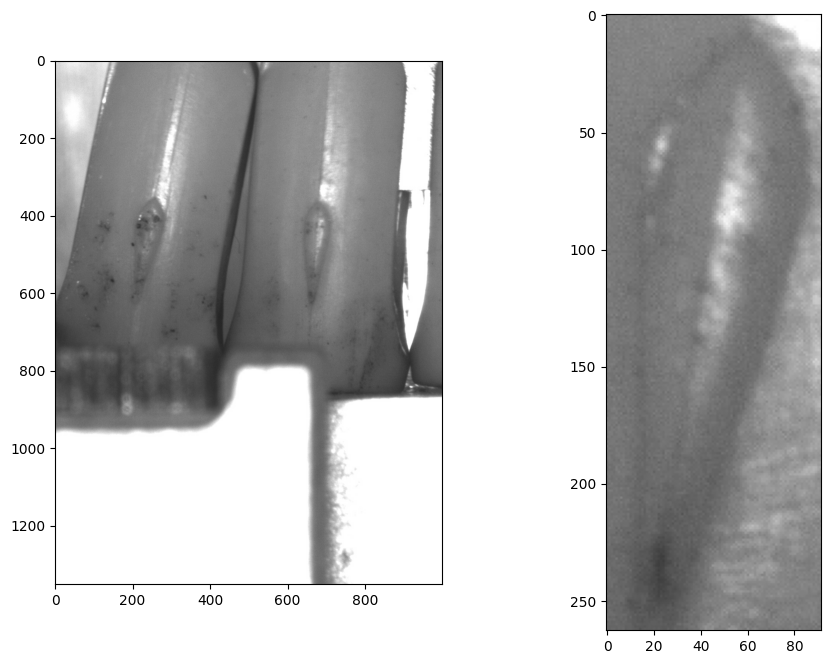

In [15]:
# Set the figure size
rcParams['figure.figsize'] = 11, 8

# Load the input image
image = Image.open(r"E:\Hachix\data\mounting_nock\nock\20251212165351_C1.jpeg").convert("RGB")
target_sizes = torch.Tensor([image.size[::-1]])

# Load the query image
query_image = Image.open(r"E:\Hachix\data\mounting_nock\nock\20251212163453_C1.jpeg").convert("RGB")
support_bbox = [[0.22065, 0.35030, 0.09222, 0.19492]] # normalized bbox [cx, cy, w, h]
# crop the support image using the bounding box
width, height = query_image.size
cx, cy, w, h = support_bbox[0]
left = int((cx - w / 2) * width)
top = int((cy - h / 2) * height)
right = int((cx + w / 2) * width)
bottom = int((cy + h / 2) * height)
query_image = query_image.crop((left, top, right, bottom))
# Display the input image and query image side by side.
fig, ax = plt.subplots(1, 2)
ax[0].imshow(image)
ax[1].imshow(query_image)

In [16]:
# Define the device to use for processing.

# Process input and query images using the preprocessor.
inputs = processor(images=image, query_images=query_image, return_tensors="pt").to(DEVICE)


In [17]:
with torch.no_grad():
  outputs = model.image_guided_detection(**inputs)

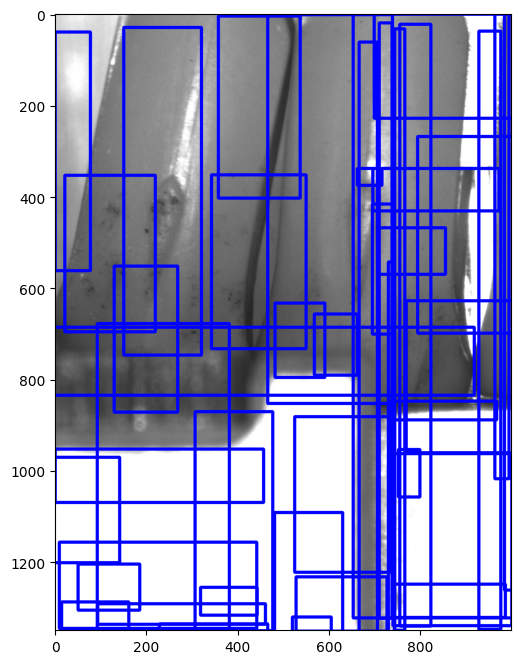

In [19]:
# Visualize the results
import numpy as np

# Convert the image to RGB format.
img = cv2.cvtColor(np.array(image), cv2.COLOR_BGR2RGB)
outputs.logits = outputs.logits.cpu()
outputs.target_pred_boxes = outputs.target_pred_boxes.cpu()

# Post-process the detection results.
results = processor.post_process_image_guided_detection(outputs=outputs, threshold=0.9, nms_threshold=0.2, target_sizes=target_sizes)
boxes, scores = results[0]["boxes"], results[0]["scores"]

# Draw bounding boxes on the image.
for box, score in zip(boxes, scores):
    box = [int(i) for i in box.tolist()]

    img = cv2.rectangle(img, box[:2], box[2:], (255, 0, 0), 5)

# Display the image with predicted bounding boxes.
plt.imshow(img[:, :, ::-1])